# Plot and Validate TESS Transits

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import batman
import lightkurve as lk
# from bls_fit import time, flux, flux_err

/opt/homebrew/anaconda3/envs/k2-19-batman-lk/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
# Time conversion
petigura_offset = 2454833
tess_offset = 2457000

def convert_time_t2p(times):
    BTJD = times + tess_offset
    return BTJD - petigura_offset

def convert_time_p2t(times):
    ### TESS offset 
    BTJD = times + petigura_offset
    new_time = BTJD - tess_offset
    return new_time

# Light curve

In [4]:
# # Download the light curve data
# lc = lk.search_lightcurve("K2-19",author = 'SPOC').download_all()
# print(lc)

In [5]:
# # Flatten the light curve
# lc = lc.stitch().flatten(window_length=901).remove_outliers()
# lc.plot()
# plt.show()
# time = lc.time
# flux=lc.flux
# flux_err = lc.flux_err

In [6]:
### mask transits 
mask_transits=True
T14_b = 3.237 * 0.0416667
T14_c = 3.823 * 0.0416667  # convert to days
### Download the light curve data
lc = lk.search_lightcurve("K2-19",author = 'SPOC').download_all()
lc = lc.stitch()

transit_guess_b = [4697.28902908, 4713.12734384, 4721.04182988, 4728.95965259, 
                   4736.88081197, 4744.79863469, 5433.87877363, 5449.72025823]

transit_guess_c = [4696.980633, 4708.8928157, 4720.80553531, 4744.63167682, 
                   5434.90727234, 5446.817015]
transit_guess_b = convert_time_p2t(np.array(transit_guess_b))
transit_guess_c = convert_time_p2t(np.array(transit_guess_c))
if mask_transits == True:
    mask_scale = 4
    ### mask transit times before flattening
    masked_lc = lc

    # times = convert_time_t2p(masked_lc.time.value)
    times = masked_lc.time.value

    ### Initialize a mask with all False values (i.e., include all data points initially)
    mask = np.zeros_like(times, dtype=bool)

    ### Iterate through each transit time and update the mask
    for transit_time in transit_guess_b:
        mask |= (times > (transit_time - T14_b/2*mask_scale)) & (times < (transit_time + T14_b/2*mask_scale))

    for transit_time in transit_guess_c:
        mask |= (times > (transit_time - T14_c/2*mask_scale)) & (times < (transit_time + T14_c/2*mask_scale))

    ### Flatten the masked light curve
    masked_lc = masked_lc.flatten(window_length=901, mask=mask).remove_outliers()
    lc = masked_lc
else:
    ### flatten unmasked lightcurve 
    lc = lc.flatten(window_length=901).remove_outliers()


In [7]:
time = lc.time
flux=lc.flux
flux_err = lc.flux_err

# Prepare time and flux
time = time.value
time = convert_time_t2p(time)

flux = flux.value
flux_err = flux_err.value

In [10]:
# Transit parameters from NASA exoplanet archive
# per_b = 7.9222
# rp_b = 0.0777
# T14_b = 3.237 * 0.0416667
# b_b = 0.17
from astropy.constants import G, M_sun, R_sun
import astropy.units as u


def semi_major_axis(P, M_star, R_star):
    '''
    P: period in days
    M_star: stellar mass in M_sun
    R_star: stellar radius in R_sun
    '''
    P_ = P * u.day
    M_star_ = M_star * M_sun
    R_star_ = R_star * R_sun
    a = ((G*M_star_*P_**2) / (4*np.pi**2))**(1./3.)
    a_stellar_radii = (a / R_star_).decompose()
    return a_stellar_radii.value


# stellar 
M_star = 0.88
R_star = 0.82

### params from Petigura et al 2020 for Kreidberg Batman
per_b = 7.9222
rp_b = 0.0777
a_b = semi_major_axis(per_b, M_star, R_star) # [stellar_radii]
inc_b = 91.5
# ecc_b = 0.10 
sesinw_b = -0.44
secosw_b = 0.02
# Compute sqrt(e)
sqrt_e = np.sqrt(sesinw_b**2 + secosw_b**2)

# Compute e
ecc_b = sqrt_e**2
import math
# Compute omega in radians
omega_rad = math.atan2(sesinw_b, secosw_b)

# Convert omega to degrees
omega_deg_b = math.degrees(omega_rad)


# q1_b = 0.4
# q2_b = 0.3
### using LDTk
u1 = 0.4437 #± 0.0018
u2 = 0.1452 #± 0.0029

In [11]:
# Transit windows
buffer = 1.5 * T14_b
df_tess = pd.read_csv('data/tess_transit_data.csv')
transit_times = np.array(df_tess["Tc(TESS)"])

# transit_times = np.array(np.loadtxt("transit_fit_jnkep_b.txt"))
# transit_times = convert_time_t2p(transit_times)
print(transit_times)


[4697.28902908 4713.12734384 4721.04182988 4728.95965259 4736.88081197
 4744.79863469 5433.87877363 5449.72025823]


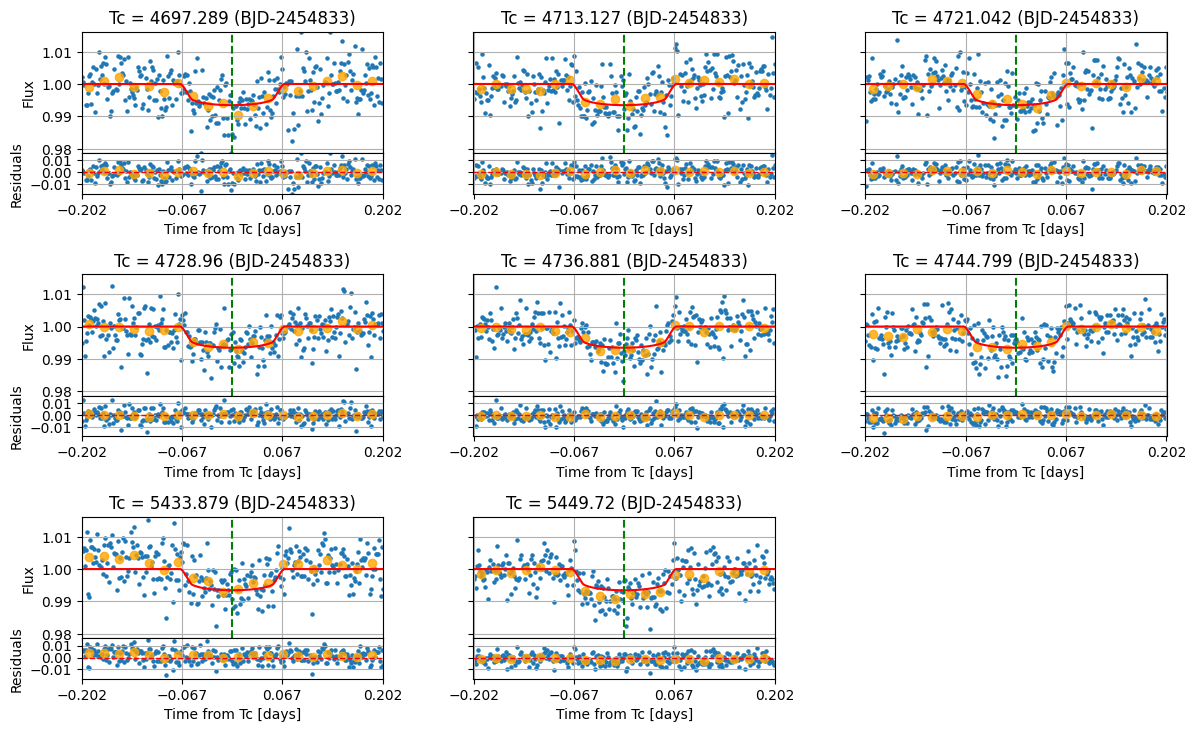

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import batman

cols = 3
rows = int(np.ceil(len(transit_times) / cols))

fig = plt.figure(figsize=(14, rows * 2.8))
outer = gridspec.GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.5)

# Track global y-limits
all_flux_values = []
all_residuals = []

# First pass: find global min/max
for t0 in transit_times:
    t_min = t0 - buffer
    t_max = t0 + buffer
    mask = (time >= t_min) & (time <= t_max)

    # Transit model
    theta_initial = [t0, per_b, rp_b, a_b, inc_b, ecc_b, omega_deg_b, u1, u2]
    params = batman.TransitParams()
    # params.t0, params.per, params.rp, params.b, params.T14, q1, q2 = theta_initial
    params.t0, params.per, params.rp, params.a, params.inc, params.ecc, params.w, u1, u2 = theta_initial

    # params.u = [2 * np.sqrt(q1) * q2, np.sqrt(q1) * (1 - 2 * q2)]
    params.u = [u1,u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, time[mask])
    model_flux = m.light_curve(params)
    residuals = flux[mask] - model_flux

    all_flux_values.extend(flux[mask])
    all_residuals.extend(residuals)

flux_ylim = [np.min(all_flux_values), np.max(all_flux_values)]
resid_ylim = [np.min(all_residuals), np.max(all_residuals)]

# Second pass: plotting
for i, t0 in enumerate(transit_times):
    row = i // cols
    col = i % cols
    inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                             height_ratios=[3, 1], hspace=0.0)

    t_min = t0 - buffer
    t_max = t0 + buffer
    mask = (time >= t_min) & (time <= t_max)
    time_rel_days = time[mask] - t0  # Time from Tc in days

    # Transit model
    theta_initial = [t0, per_b, rp_b, a_b, inc_b, ecc_b, omega_deg_b, u1, u2]
    params = batman.TransitParams()
    # params.t0, params.per, params.rp, params.b, params.T14, q1, q2 = theta_initial
    params.t0, params.per, params.rp, params.a, params.inc, params.ecc, params.w, u1, u2 = theta_initial

    # params.u = [2 * np.sqrt(q1) * q2, np.sqrt(q1) * (1 - 2 * q2)]
    params.u = [u1,u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, time[mask])
    model_flux = m.light_curve(params)
    residuals = flux[mask] - model_flux

    # Top panel: flux
    ax1 = fig.add_subplot(inner[0])
    ax1.scatter(time_rel_days, flux[mask], s=5)
    ax1.plot(time_rel_days, model_flux, color='red')
    ax1.axvline(0, color='green', linestyle='--')
    ax1.set_xlim(-buffer, buffer)
    ax1.set_ylim(flux_ylim)
    ax1.set_title(f'Tc = {round(t0, 3)} (BJD-{petigura_offset})')
    ax1.grid(True)
    ax1.tick_params(labelbottom=False)

    # Bottom panel: residuals
    ax2 = fig.add_subplot(inner[1], sharex=ax1)
    ax2.scatter(time_rel_days, residuals, s=5)
    ax2.axhline(0, color='red', linestyle='--', linewidth=1)
    ax2.set_xlim(-buffer, buffer)
    ax2.set_ylim(resid_ylim)
    ax2.set_xlabel("Time from Tc [days]")
    ax2.grid(True)

    # Y-axis only on first column
    if col == 0:
        ax1.set_ylabel("Flux")
        ax2.set_ylabel("Residuals")
    else:
        ax1.set_ylabel("")
        ax1.tick_params(labelleft=False)
        ax2.set_ylabel("")
        ax2.tick_params(labelleft=False)

    # Custom x-ticks
    ticks = np.round(np.linspace(-buffer, buffer, 4), 3)
    ax2.set_xticks(ticks)
    # Binned points
    bin_width = 0.02  # Adjust as needed
    bins = np.arange(-buffer, buffer + bin_width, bin_width)
    digitized = np.digitize(time_rel_days, bins)
    binned_flux = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
    binned_residuals = [residuals[digitized == i].mean() for i in range(1, len(bins))]
    ax1.scatter(bins[:-1] + bin_width / 2, binned_flux, marker='o', color='orange', alpha=0.8)
    ax2.scatter(bins[:-1] + bin_width / 2, binned_residuals, marker='o', color='orange', alpha=0.8)


plt.show()


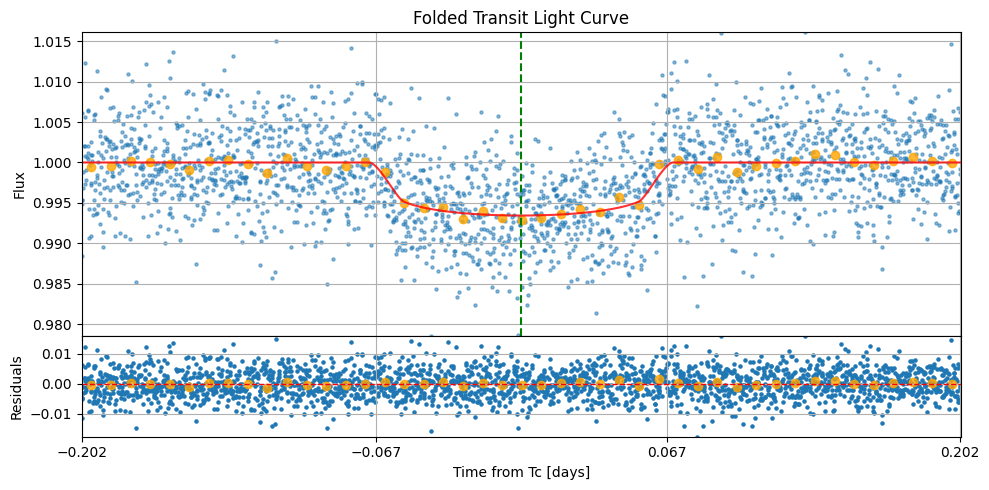

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import batman

# --- Prepare figure ---
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.0)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# --- Fold and collect data ---
all_folded_time = []
all_folded_flux = []
all_folded_model = []
all_folded_residuals = []

for t0 in transit_times:
    t_min = t0 - buffer
    t_max = t0 + buffer
    mask = (time >= t_min) & (time <= t_max)
    t_segment = time[mask]
    f_segment = flux[mask]
    
    folded_time = (t_segment - t0 + 0.5 * per_b) % per_b - 0.5 * per_b

    # Transit model centered at t0
    params = batman.TransitParams()
    params.t0 = t0
    params.per = per_b
    params.rp = rp_b
    params.a = a_b
    params.inc = inc_b
    params.ecc = ecc_b
    params.w = omega_deg_b
    params.u = [u1, u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, t_segment)
    model_flux = m.light_curve(params)
    residuals = f_segment - model_flux

    all_folded_time.extend(folded_time)
    all_folded_flux.extend(f_segment)
    all_folded_model.extend(model_flux)
    all_folded_residuals.extend(residuals)

all_folded_time = np.array(all_folded_time)
all_folded_flux = np.array(all_folded_flux)
all_folded_model = np.array(all_folded_model)
all_folded_residuals = np.array(all_folded_residuals)

# --- Sort model vs. folded time so the model line is smooth ---
sorted_idx = np.argsort(all_folded_time)
sorted_time = all_folded_time[sorted_idx]
sorted_model = all_folded_model[sorted_idx]

# --- Plot raw folded data and model ---
ax1.scatter(all_folded_time, all_folded_flux, s=5, alpha=0.5)
ax1.plot(sorted_time, sorted_model, color='red', linewidth=1.5, alpha=0.8)
ax1.axvline(0, color='green', linestyle='--')
ax1.set_xlim(-buffer, buffer)
ax1.set_ylim(np.min(all_folded_flux), np.max(all_folded_flux))
ax1.set_ylabel("Flux")
ax1.grid(True)
ax1.tick_params(labelbottom=False)
ax1.set_title("Folded Transit Light Curve")

# --- Residuals ---
ax2.scatter(all_folded_time, all_folded_residuals, s=5)
ax2.axhline(0, color='red', linestyle='--', linewidth=1)
ax2.set_xlim(-buffer, buffer)
ax2.set_ylim(np.min(all_folded_residuals), np.max(all_folded_residuals))
ax2.set_xlabel("Time from Tc [days]")
ax2.set_ylabel("Residuals")
ax2.grid(True)

# --- Binned points ---
bin_width = 0.009
bins = np.arange(-buffer, buffer + bin_width, bin_width)
digitized = np.digitize(all_folded_time, bins)
bin_centers = bins[:-1] + bin_width / 2

binned_flux = [
    all_folded_flux[digitized == i].mean() if np.any(digitized == i) else np.nan
    for i in range(1, len(bins))
]
binned_resid = [
    all_folded_residuals[digitized == i].mean() if np.any(digitized == i) else np.nan
    for i in range(1, len(bins))
]

# Plot binned data
ax1.scatter(bin_centers, binned_flux, marker='o', color='orange', alpha=0.8)
ax2.scatter(bin_centers, binned_resid, marker='o', color='orange', alpha=0.8)

# Custom ticks
ticks = np.round(np.linspace(-buffer, buffer, 4), 3)
ax2.set_xticks(ticks)

plt.tight_layout()
plt.show()


# Predicted times for planet c

In [15]:
### params from exoplanet archive
per_c = 11.8993
rp_c = 0.0458
T14_c = 3.823 * 0.0416667  # convert to days
b_c = 0.630

### params from Petigura et al 2020 for Kreidberg Batman
per_c = 11.8993
rp_c = 0.0458
a_c = semi_major_axis(per_c, M_star, R_star) # [stellar_radii]
inc_c = 91.1
# ecc_c = 0.10 
sesinw_c = -0.46
secosw_c = 0.04
# Compute sqrt(e)
sqrt_e = np.sqrt(sesinw_c**2 + secosw_c**2)

# Compute e
ecc_c = sqrt_e**2
import math
# Compute omega in radians
omega_rad = math.atan2(sesinw_c, secosw_c)

# Convert omega to degrees
omega_deg_c = math.degrees(omega_rad)

In [16]:
# Transit windows
buffer = 1.5 * T14_c
transit_times = np.array(np.loadtxt("data/transit_pred_jnkep_c.txt"))
transit_times = convert_time_t2p(transit_times)
print(transit_times)

[4696.980633   4708.8928157  4720.80553531 4744.63167682 5434.90727234
 5446.817015  ]


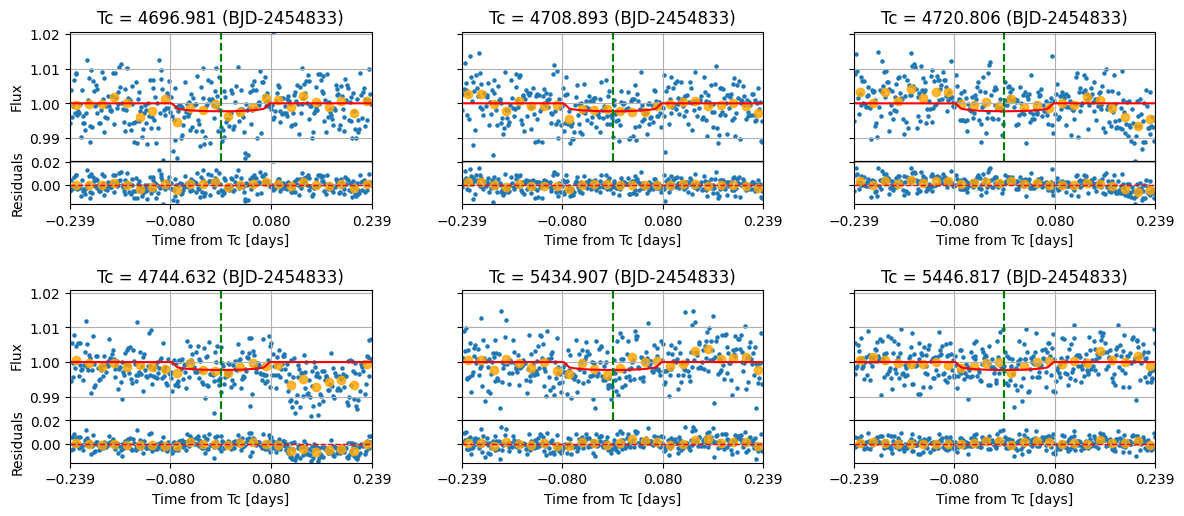

In [18]:
cols = 3
rows = int(np.ceil(len(transit_times) / cols))

fig = plt.figure(figsize=(14, rows * 2.8))
outer = gridspec.GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.5)

# Track global y-limits
all_flux_values = []
all_residuals = []

# First pass: find global min/max
for t0 in transit_times:
    t_min = t0 - buffer
    t_max = t0 + buffer
    mask = (time >= t_min) & (time <= t_max)

    # Transit model
    theta_initial = [t0, per_c, rp_c, a_c, inc_c, ecc_c, omega_deg_c, u1, u2]
    params = batman.TransitParams()
    # params.t0, params.per, params.rp, params.b, params.T14, q1, q2 = theta_initial
    params.t0, params.per, params.rp, params.a, params.inc, params.ecc, params.w, u1, u2 = theta_initial

    # params.u = [2 * np.sqrt(q1) * q2, np.sqrt(q1) * (1 - 2 * q2)]
    params.u = [u1,u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, time[mask])
    model_flux = m.light_curve(params)
    residuals = flux[mask] - model_flux

    all_flux_values.extend(flux[mask])
    all_residuals.extend(residuals)

flux_ylim = [np.min(all_flux_values), np.max(all_flux_values)]
resid_ylim = [np.min(all_residuals), np.max(all_residuals)]

# Second pass: plotting
for i, t0 in enumerate(transit_times):
    row = i // cols
    col = i % cols
    inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                             height_ratios=[3, 1], hspace=0.0)

    t_min = t0 - buffer
    t_max = t0 + buffer
    mask = (time >= t_min) & (time <= t_max)
    time_rel_days = time[mask] - t0  # Time from Tc in days

    # Transit model
    theta_initial = [t0, per_c, rp_c, a_c, inc_c, ecc_c, omega_deg_c, u1, u2]
    params = batman.TransitParams()
    # params.t0, params.per, params.rp, params.b, params.T14, q1, q2 = theta_initial
    params.t0, params.per, params.rp, params.a, params.inc, params.ecc, params.w, u1, u2 = theta_initial

    # params.u = [2 * np.sqrt(q1) * q2, np.sqrt(q1) * (1 - 2 * q2)]
    params.u = [u1,u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, time[mask])
    model_flux = m.light_curve(params)
    residuals = flux[mask] - model_flux

    # Top panel: flux
    ax1 = fig.add_subplot(inner[0])
    ax1.scatter(time_rel_days, flux[mask], s=5)
    ax1.plot(time_rel_days, model_flux, color='red')
    ax1.axvline(0, color='green', linestyle='--')
    ax1.set_xlim(-buffer, buffer)
    ax1.set_ylim(flux_ylim)
    ax1.set_title(f'Tc = {round(t0, 3)} (BJD-{petigura_offset})')
    ax1.grid(True)
    ax1.tick_params(labelbottom=False)

    # Bottom panel: residuals
    ax2 = fig.add_subplot(inner[1], sharex=ax1)
    ax2.scatter(time_rel_days, residuals, s=5)
    ax2.axhline(0, color='red', linestyle='--', linewidth=1)
    ax2.set_xlim(-buffer, buffer)
    ax2.set_ylim(resid_ylim)
    ax2.set_xlabel("Time from Tc [days]")
    ax2.grid(True)

    # Y-axis only on first column
    if col == 0:
        ax1.set_ylabel("Flux")
        ax2.set_ylabel("Residuals")
    else:
        ax1.set_ylabel("")
        ax1.tick_params(labelleft=False)
        ax2.set_ylabel("")
        ax2.tick_params(labelleft=False)

    # Custom x-ticks
    ticks = np.round(np.linspace(-buffer, buffer, 4), 3)
    ax2.set_xticks(ticks)
    # Binned points
    bin_width = 0.02  # Adjust as needed
    bins = np.arange(-buffer, buffer + bin_width, bin_width)
    digitized = np.digitize(time_rel_days, bins)
    binned_flux = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
    binned_residuals = [residuals[digitized == i].mean() for i in range(1, len(bins))]
    ax1.scatter(bins[:-1] + bin_width / 2, binned_flux, marker='o', color='orange', alpha=0.8)
    ax2.scatter(bins[:-1] + bin_width / 2, binned_residuals, marker='o', color='orange', alpha=0.8)


plt.show()



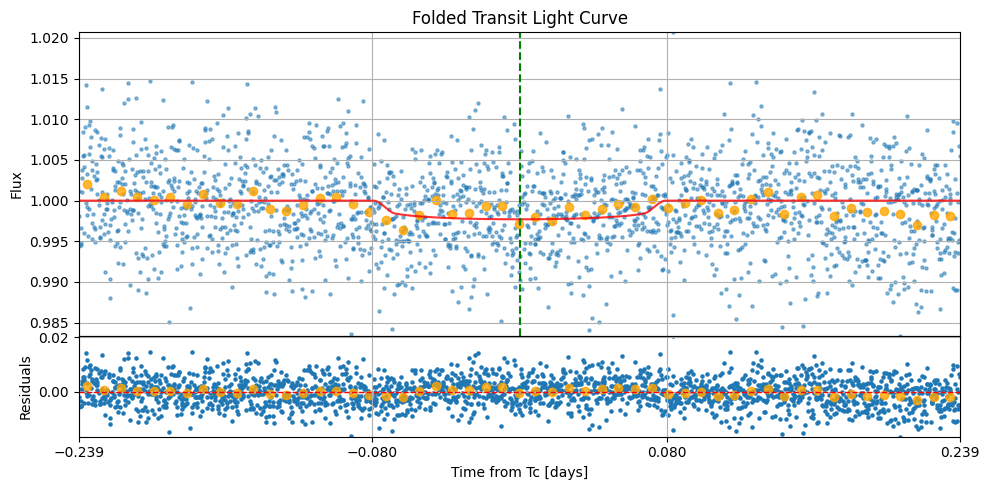

In [19]:
# --- Prepare figure ---
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.0)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# --- Fold and collect data ---
all_folded_time = []
all_folded_flux = []
all_folded_model = []
all_folded_residuals = []

for t0 in transit_times:
    t_min = t0 - buffer
    t_max = t0 + buffer
    mask = (time >= t_min) & (time <= t_max)
    t_segment = time[mask]
    f_segment = flux[mask]
    
    folded_time = (t_segment - t0 + 0.5 * per_c) % per_c - 0.5 * per_c

    # Transit model centered at t0
    params = batman.TransitParams()
    params.t0 = t0
    params.per = per_c
    params.rp = rp_c
    params.a = a_c
    params.inc = inc_c
    params.ecc = ecc_c
    params.w = omega_deg_c
    params.u = [u1, u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, t_segment)
    model_flux = m.light_curve(params)
    residuals = f_segment - model_flux

    all_folded_time.extend(folded_time)
    all_folded_flux.extend(f_segment)
    all_folded_model.extend(model_flux)
    all_folded_residuals.extend(residuals)

all_folded_time = np.array(all_folded_time)
all_folded_flux = np.array(all_folded_flux)
all_folded_model = np.array(all_folded_model)
all_folded_residuals = np.array(all_folded_residuals)

# --- Sort model vs. folded time so the model line is smooth ---
sorted_idx = np.argsort(all_folded_time)
sorted_time = all_folded_time[sorted_idx]
sorted_model = all_folded_model[sorted_idx]

# --- Plot raw folded data and model ---
ax1.scatter(all_folded_time, all_folded_flux, s=5, alpha=0.5)
ax1.plot(sorted_time, sorted_model, color='red', linewidth=1.5, alpha=0.8)
ax1.axvline(0, color='green', linestyle='--')
ax1.set_xlim(-buffer, buffer)
ax1.set_ylim(np.min(all_folded_flux), np.max(all_folded_flux))
ax1.set_ylabel("Flux")
ax1.grid(True)
ax1.tick_params(labelbottom=False)
ax1.set_title("Folded Transit Light Curve")

# --- Residuals ---
ax2.scatter(all_folded_time, all_folded_residuals, s=5)
ax2.axhline(0, color='red', linestyle='--', linewidth=1)
ax2.set_xlim(-buffer, buffer)
ax2.set_ylim(np.min(all_folded_residuals), np.max(all_folded_residuals))
ax2.set_xlabel("Time from Tc [days]")
ax2.set_ylabel("Residuals")
ax2.grid(True)

# --- Binned points ---
bin_width = 0.009
bins = np.arange(-buffer, buffer + bin_width, bin_width)
digitized = np.digitize(all_folded_time, bins)
bin_centers = bins[:-1] + bin_width / 2

binned_flux = [
    all_folded_flux[digitized == i].mean() if np.any(digitized == i) else np.nan
    for i in range(1, len(bins))
]
binned_resid = [
    all_folded_residuals[digitized == i].mean() if np.any(digitized == i) else np.nan
    for i in range(1, len(bins))
]

# Plot binned data
ax1.scatter(bin_centers, binned_flux, marker='o', color='orange', alpha=0.8)
ax2.scatter(bin_centers, binned_resid, marker='o', color='orange', alpha=0.8)

# Custom ticks
ticks = np.round(np.linspace(-buffer, buffer, 4), 3)
ax2.set_xticks(ticks)

plt.tight_layout()
plt.show()
